# RAG vs LLM-only Evaluation Results

Analiza porównawcza odpowiedzi systemu RAG (Retrieval-Augmented Generation) vs czystego LLM na 100 pytaniach z zakresu Threat Intelligence.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE = {
    "rag": "#3498db",
    "llm": "#e67e22", 
    "tie": "#95a5a6",
    "accent": "#2c3e50"
}

## Wczytanie danych

In [2]:
eval_dir = Path("../data/evaluation")

eval_file = eval_dir / "evaluation.json"
benchmark_file = eval_dir / "benchmark.json"

print(f"Plik ewaluacji: {eval_file.name}")
print(f"Plik benchmarku: {benchmark_file.name}")

with open(eval_file) as f:
    eval_data = json.load(f)

with open(benchmark_file) as f:
    benchmark_data = json.load(f)

Plik ewaluacji: evaluation.json
Plik benchmarku: benchmark.json


In [3]:
print("Metadata Benchmarku")
print("-" * 40)
for k, v in benchmark_data["metadata"].items():
    print(f"  {k}: {v}")

print("\nMetadata Ewaluacji")
print("-" * 40)
for k, v in eval_data["metadata"].items():
    print(f"  {k}: {v}")

Metadata Benchmarku
----------------------------------------
  run_id: benchmark_20260102_001031
  mode: both
  backend: openrouter
  model: openai/gpt-oss-20b
  concurrency: 20
  total_questions: 100
  timestamp: 2026-01-02T00:10:31.187599

Metadata Ewaluacji
----------------------------------------
  benchmark_file: data/evaluation/benchmark.json
  judge_model: openai/gpt-oss-120b
  use_llm_judge: True
  timestamp: 2026-01-02T00:11:24.020641
  total_time_seconds: 24.66535782814026


## Przygotowanie DataFrame

In [4]:
records = []
for e in eval_data["evaluations"]:
    record = {
        "question_type": e["question_type"],
        "difficulty": e["difficulty"],
        "rag_score": e["rag"]["score"] if e.get("rag") else None,
        "llm_only_score": e["llm_only"]["score"] if e.get("llm_only") else None,
    }
    records.append(record)

df = pd.DataFrame(records)
df["score_diff"] = df["rag_score"] - df["llm_only_score"]
df["winner"] = df["score_diff"].apply(lambda x: "RAG" if x > 0 else ("LLM-only" if x < 0 else "Tie"))

print(f"Liczba pytań: {len(df)}")
df.head(10)

Liczba pytań: 100


,question_type,difficulty,rag_score,llm_only_score,score_diff,winner
0,FACTUAL,easy,1,1,0,Tie
1,FACTUAL,easy,1,0,1,RAG
2,FACTUAL,easy,1,2,-1,LLM-only
3,FACTUAL,easy,3,1,2,RAG
4,FACTUAL,easy,1,1,0,Tie
5,FACTUAL,medium,1,1,0,Tie
6,FACTUAL,easy,3,1,2,RAG
7,FACTUAL,easy,2,1,1,RAG
8,FACTUAL,easy,4,1,3,RAG
9,FACTUAL,easy,1,1,0,Tie


## Podsumowanie wyników

In [5]:
summary = eval_data["summary"]

print("PODSUMOWANIE EWALUACJI RAG vs LLM-only")
print("-" * 45)
print(f"\nLiczba pytań: {summary['total_evaluated']}")
print(f"\nŚredni wynik (skala 1-5):")
print(f"  RAG:      {summary['rag']['avg_score']:.2f}")
print(f"  LLM-only: {summary['llm_only']['avg_score']:.2f}")
print(f"  Różnica:  {summary['rag']['avg_score'] - summary['llm_only']['avg_score']:.2f} ({(summary['rag']['avg_score'] / summary['llm_only']['avg_score'] - 1) * 100:.1f}% lepiej dla RAG)")
print(f"\nHead-to-head:")
print(f"  RAG wygrywa:      {summary['comparison']['rag_wins']}")
print(f"  LLM-only wygrywa: {summary['comparison']['llm_only_wins']}")
print(f"  Remisy:           {summary['comparison']['ties']}")

PODSUMOWANIE EWALUACJI RAG vs LLM-only
---------------------------------------------

Liczba pytań: 100

Średni wynik (skala 1-5):
  RAG:      2.44
  LLM-only: 1.50
  Różnica:  0.94 (62.7% lepiej dla RAG)

Head-to-head:
  RAG wygrywa:      52
  LLM-only wygrywa: 7
  Remisy:           41


## Porównanie średnich wyników

/var/folders/gf/4h6dwf3118q7qmg__cbhskkh0000gn/T/ipykernel_44669/877828346.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x="Method", y="Score", palette=[PALETTE["rag"], PALETTE["llm"]], ax=ax, width=0.6)


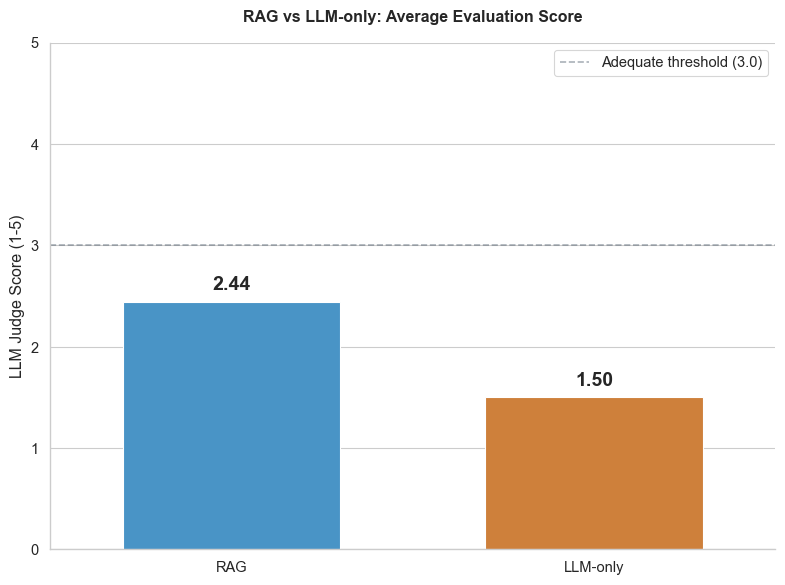

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

data = pd.DataFrame({
    "Method": ["RAG", "LLM-only"],
    "Score": [summary["rag"]["avg_score"], summary["llm_only"]["avg_score"]]
})

sns.barplot(data=data, x="Method", y="Score", palette=[PALETTE["rag"], PALETTE["llm"]], ax=ax, width=0.6)

for i, (method, score) in enumerate(zip(data["Method"], data["Score"])):
    ax.text(i, score + 0.08, f"{score:.2f}", ha="center", va="bottom", fontsize=14, fontweight="bold")

ax.set_ylabel("LLM Judge Score (1-5)")
ax.set_xlabel("")
ax.set_title("RAG vs LLM-only: Average Evaluation Score", fontweight="bold", pad=15)
ax.set_ylim(0, 5)
ax.axhline(y=3, color=PALETTE["accent"], linestyle="--", alpha=0.4, label="Adequate threshold (3.0)")
ax.legend(frameon=True, fancybox=True)

sns.despine()
plt.tight_layout()
plt.savefig("images/chart_avg_scores.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## Head-to-head

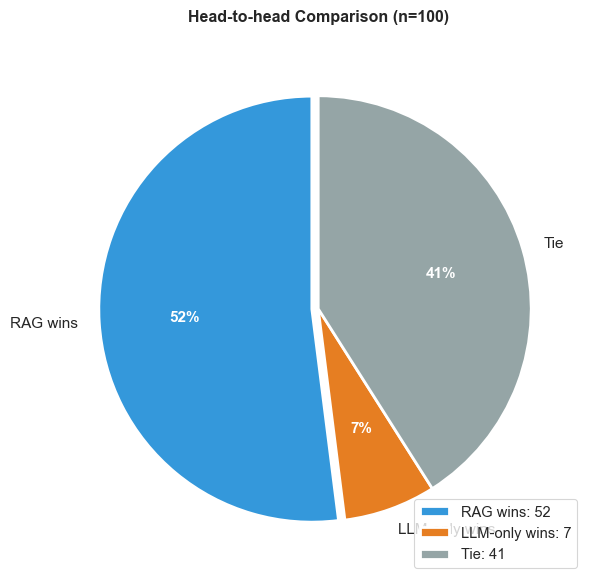

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

comp = summary["comparison"]
categories = ["RAG wins", "LLM-only wins", "Tie"]
values = [comp["rag_wins"], comp["llm_only_wins"], comp["ties"]]
colors = [PALETTE["rag"], PALETTE["llm"], PALETTE["tie"]]

wedges, texts, autotexts = ax.pie(
    values, labels=categories, autopct="%1.0f%%", 
    colors=colors, explode=(0.03, 0, 0),
    textprops={"fontsize": 11}, startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

for autotext in autotexts:
    autotext.set_fontweight("bold")
    autotext.set_color("white")

ax.set_title("Head-to-head Comparison (n=100)", fontweight="bold", pad=15)

legend_labels = [f"{cat}: {val}" for cat, val in zip(categories, values)]
ax.legend(wedges, legend_labels, loc="lower right", frameon=True, fancybox=True)

plt.tight_layout()
plt.savefig("images/chart_head_to_head.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## Wyniki według typu pytania

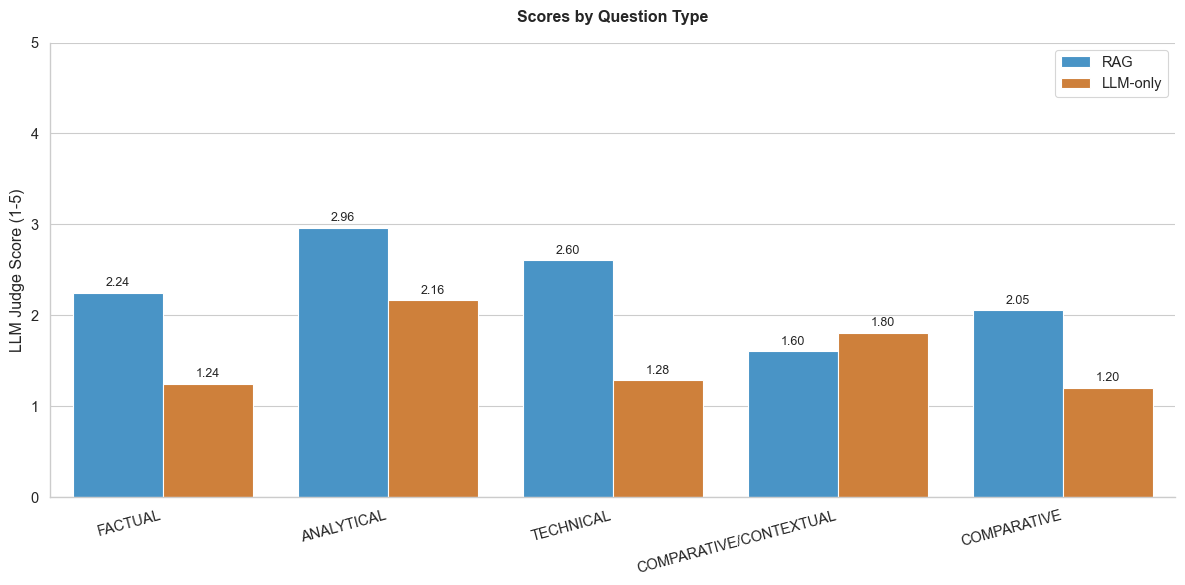

In [8]:
by_type = summary["by_question_type"]
types = list(by_type.keys())

data = pd.DataFrame([
    {"Type": t, "Method": "RAG", "Score": by_type[t]["rag"]} for t in types
] + [
    {"Type": t, "Method": "LLM-only", "Score": by_type[t]["llm_only"]} for t in types
])

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=data, x="Type", y="Score", hue="Method", 
            palette=[PALETTE["rag"], PALETTE["llm"]], ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9, padding=3)

ax.set_ylabel("LLM Judge Score (1-5)")
ax.set_xlabel("")
ax.set_title("Scores by Question Type", fontweight="bold", pad=15)
ax.set_ylim(0, 5)
ax.legend(title="", frameon=True, fancybox=True)
plt.xticks(rotation=15, ha="right")

sns.despine()
plt.tight_layout()
plt.savefig("images/chart_by_type.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## Wyniki według poziomu trudności

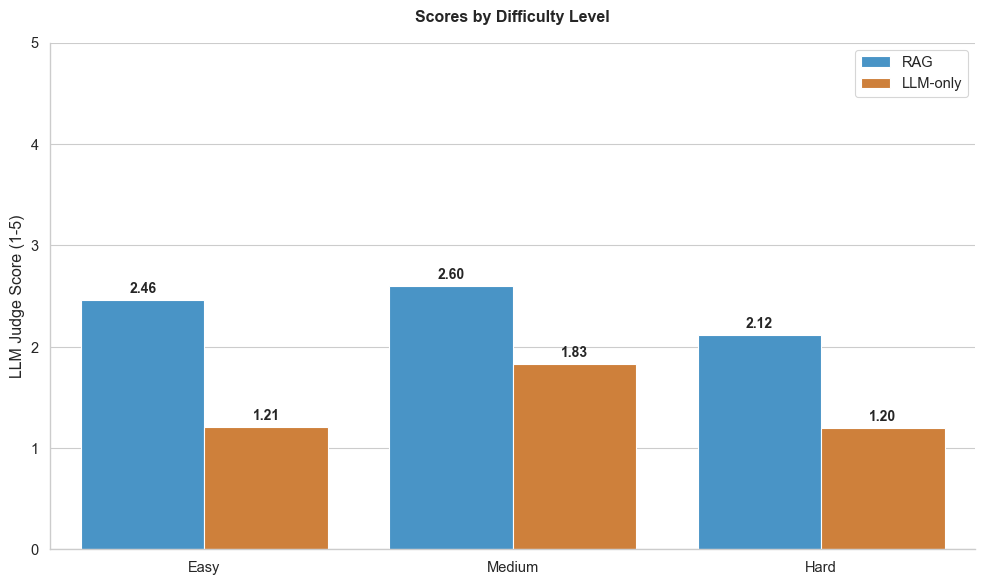

In [9]:
by_diff = summary["by_difficulty"]
diff_order = ["easy", "medium", "hard"]
diffs = [d for d in diff_order if d in by_diff]

data = pd.DataFrame([
    {"Difficulty": d.capitalize(), "Method": "RAG", "Score": by_diff[d]["rag"]} for d in diffs
] + [
    {"Difficulty": d.capitalize(), "Method": "LLM-only", "Score": by_diff[d]["llm_only"]} for d in diffs
])

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=data, x="Difficulty", y="Score", hue="Method",
            palette=[PALETTE["rag"], PALETTE["llm"]], ax=ax,
            order=[d.capitalize() for d in diff_order if d in by_diff])

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=10, fontweight="bold", padding=3)

ax.set_ylabel("LLM Judge Score (1-5)")
ax.set_xlabel("")
ax.set_title("Scores by Difficulty Level", fontweight="bold", pad=15)
ax.set_ylim(0, 5)
ax.legend(title="", frameon=True, fancybox=True)

sns.despine()
plt.tight_layout()
plt.savefig("images/chart_by_difficulty.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## Rozkład wyników

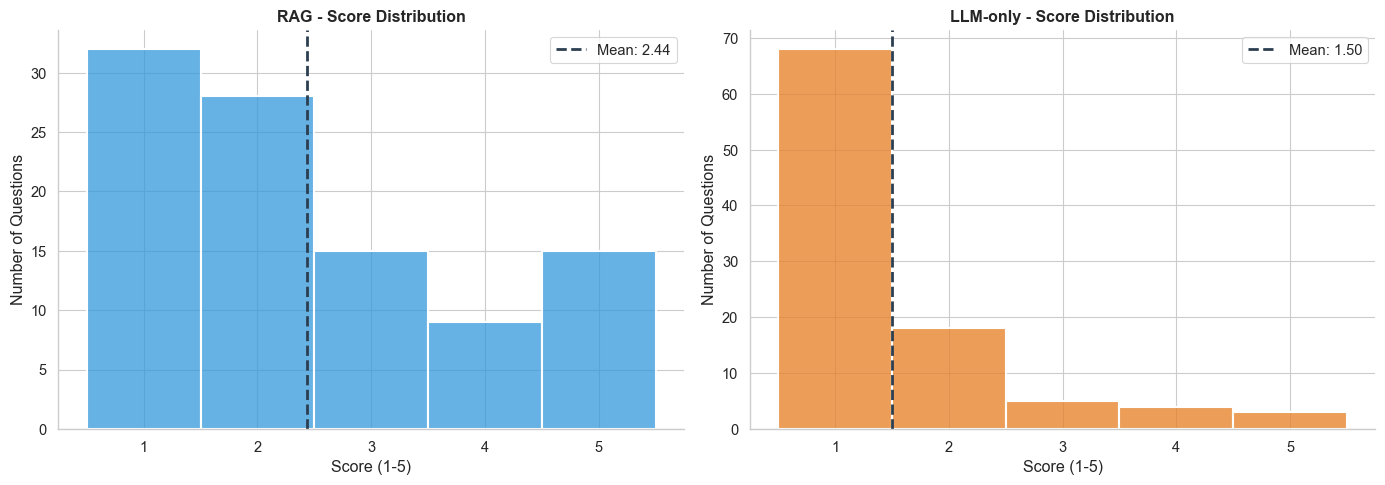

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]

sns.histplot(df["rag_score"].dropna(), bins=bins, color=PALETTE["rag"], 
             ax=axes[0], edgecolor="white", linewidth=1.5)
axes[0].set_xlabel("Score (1-5)")
axes[0].set_ylabel("Number of Questions")
axes[0].set_title("RAG - Score Distribution", fontweight="bold")
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].axvline(df["rag_score"].mean(), color=PALETTE["accent"], linestyle="--", linewidth=2,
                label=f"Mean: {df['rag_score'].mean():.2f}")
axes[0].legend(frameon=True, fancybox=True)

sns.histplot(df["llm_only_score"].dropna(), bins=bins, color=PALETTE["llm"],
             ax=axes[1], edgecolor="white", linewidth=1.5)
axes[1].set_xlabel("Score (1-5)")
axes[1].set_ylabel("Number of Questions")
axes[1].set_title("LLM-only - Score Distribution", fontweight="bold")
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].axvline(df["llm_only_score"].mean(), color=PALETTE["accent"], linestyle="--", linewidth=2,
                label=f"Mean: {df['llm_only_score'].mean():.2f}")
axes[1].legend(frameon=True, fancybox=True)

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("images/chart_distribution.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## Statystyki szczegółowe

In [11]:
print("Statystyki RAG")
print("-" * 30)
print(df["rag_score"].describe())

print("\nStatystyki LLM-only")
print("-" * 30)
print(df["llm_only_score"].describe())

print("\nTest statystyczny")
print("-" * 30)
from scipy import stats
t_stat, p_value = stats.ttest_rel(df["rag_score"], df["llm_only_score"])
print(f"Paired t-test: t={t_stat:.3f}, p-value={p_value:.6f}")
if p_value < 0.05:
    print("Różnica jest statystycznie istotna (p < 0.05)")
else:
    print("Różnica NIE jest statystycznie istotna (p >= 0.05)")

Statystyki RAG
------------------------------
count    100.000000
mean       2.440000
std        1.430688
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        5.000000
Name: rag_score, dtype: float64

Statystyki LLM-only
------------------------------
count    100.0
mean       1.5
std        1.0
min        0.0
25%        1.0
50%        1.0
75%        2.0
max        5.0
Name: llm_only_score, dtype: float64

Test statystyczny
------------------------------
Paired t-test: t=7.017, p-value=0.000000
Różnica jest statystycznie istotna (p < 0.05)


## Wnioski

In [12]:
rag_avg = summary["rag"]["avg_score"]
llm_avg = summary["llm_only"]["avg_score"]
improvement = (rag_avg / llm_avg - 1) * 100

by_type = summary["by_question_type"]
best_type = max(by_type.items(), key=lambda x: x[1]["rag"] - x[1]["llm_only"])
worst_type = min(by_type.items(), key=lambda x: x[1]["rag"] - x[1]["llm_only"])

print("WNIOSKI Z EWALUACJI")
print("-" * 50)
print(f"""
RAG vs LLM-only na 100 pytaniach z threat intelligence:

Wyniki ogólne:
  - RAG: {rag_avg:.2f}/5, LLM-only: {llm_avg:.2f}/5
  - RAG lepszy o {improvement:.1f}%
  - Różnica statystycznie istotna (p < 0.05)

Head-to-head (100 pytań):
  - RAG wygrywa: {summary['comparison']['rag_wins']}
  - LLM-only wygrywa: {summary['comparison']['llm_only_wins']}
  - Remisy: {summary['comparison']['ties']}

Gdzie RAG najlepiej wypada:
  - Typ: {best_type[0]} (RAG {best_type[1]['rag']:.2f} vs LLM {best_type[1]['llm_only']:.2f})
  - Pytania wymagające konkretnych faktów z dokumentów
  - Szczegóły techniczne (IoC, nazwy plików, komendy)

Gdzie różnica najmniejsza:
  - Typ: {worst_type[0]} (RAG {worst_type[1]['rag']:.2f} vs LLM {worst_type[1]['llm_only']:.2f})

Ograniczenia:
  - Oba systemy poniżej progu 3/5 (adequate)
  - Model {benchmark_data['metadata']['model']} ma ograniczoną wiedzę o threat intelligence
  - Potencjał poprawy: lepszy retrieval, większy model, fine-tuning
""")

WNIOSKI Z EWALUACJI
--------------------------------------------------

RAG vs LLM-only na 100 pytaniach z threat intelligence:

Wyniki ogólne:
  - RAG: 2.44/5, LLM-only: 1.50/5
  - RAG lepszy o 62.7%
  - Różnica statystycznie istotna (p < 0.05)

Head-to-head (100 pytań):
  - RAG wygrywa: 52
  - LLM-only wygrywa: 7
  - Remisy: 41

Gdzie RAG najlepiej wypada:
  - Typ: TECHNICAL (RAG 2.60 vs LLM 1.28)
  - Pytania wymagające konkretnych faktów z dokumentów
  - Szczegóły techniczne (IoC, nazwy plików, komendy)

Gdzie różnica najmniejsza:
  - Typ: COMPARATIVE/CONTEXTUAL (RAG 1.60 vs LLM 1.80)

Ograniczenia:
  - Oba systemy poniżej progu 3/5 (adequate)
  - Model openai/gpt-oss-20b ma ograniczoną wiedzę o threat intelligence
  - Potencjał poprawy: lepszy retrieval, większy model, fine-tuning



## Przykładowa odpowiedź

In [13]:
best_idx = df["score_diff"].idxmax()
best_rag = benchmark_data["results"][best_idx]

print(f"Pytanie (najwyższa przewaga RAG, diff={df.loc[best_idx, 'score_diff']:.0f}):")
print("-" * 50)
print(f"{best_rag['question']}")

print(f"\nOczekiwana odpowiedź:")
for p in best_rag['expected_answer']['points']:
    print(f"  - {p}")

print(f"\nRAG (score: {df.loc[best_idx, 'rag_score']:.0f}/5):")
print(best_rag['rag']['answer'][:600] + "...")

print(f"\nLLM-only (score: {df.loc[best_idx, 'llm_only_score']:.0f}/5):")
print(best_rag['llm_only']['answer'][:600] + "...")

Pytanie (najwyższa przewaga RAG, diff=4):
--------------------------------------------------
What percentage of ransom payouts do REvil affiliates receive based on their performance?

Oczekiwana odpowiedź:
  - Affiliates receive between 60% and 75% of payouts
  - The percentage depends on affiliate performance
  - REvil operates as a Ransomware-as-a-Service (RaaS) model with vetted affiliates who buy in

RAG (score: 5/5):
The supplied threat‑intelligence reports do not contain any information about the payout structure or percentages that REvil (Sodinokibi) affiliates receive. Consequently, there is no factual basis from these documents to answer how much of a ransom payment affiliates get based on their performance....

LLM-only (score: 1/5):
**Typical revenue split for REvil (Sodinokibi) affiliates**

| Distribution | Approximately | Notes |
|---------------|---------------|-------|
| **Affiliate share** | ~70 – 80 % of the ransom cash | This fraction can fluctuate. Affiliates who pe